# **UTN Santa Fe - Ciencia de Datos**
## *TP N°1 - Parte 1: Análisis exploratorio de datos*


---
### **Librerías**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### **Carga del conjunto de datos**
Realizamos la lectura del archivo `i40 (datos).csv` y visualizamos las primeras filas para comprobar que haya cargado correctamente.

In [2]:
# Carga de datos
df = pd.read_csv('i40 (datos).csv')
df.columns = df.columns.str.strip()

# Visualización de las primeras filas para comprobar que cargó correctamente
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


---
### **Medidas de tendencia central**
Comenzamos calculando la media para cada columna:

In [3]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
    # Verificamos si la columna es numérica antes de calcular
        if pd.api.types.is_numeric_dtype(df[columna]):
            print(f"Media de {columna}: {df[columna].mean():.2f}")

Media de air_temp [K]: 300.48
Media de process_temp [K]: 310.17
Media de speed [RPM]: 1513.39
Media de torque [Nm]: 44.96
Media de tool_wear [min]: 124.92


A continuación, calculamos la mediana:

In [4]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
        # Verificamos si la columna es numérica antes de calcular
        if pd.api.types.is_numeric_dtype(df[columna]):
            print(f"Mediana de {columna}: {df[columna].median():.2f}")

Mediana de air_temp [K]: 300.60
Mediana de process_temp [K]: 310.32
Mediana de speed [RPM]: 1423.00
Mediana de torque [Nm]: 46.70
Mediana de tool_wear [min]: 127.00


Por último, calculamos la moda:

In [5]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
        print(f"Moda de {columna}: {df[columna].mode()[0]}")

Moda de product_type: L
Moda de air_temp [K]: 300.7
Moda de process_temp [K]: 310.6
Moda de speed [RPM]: 1377
Moda de torque [Nm]: 35.8
Moda de tool_wear [min]: 208
Moda de target: failure


---
### **Medidas de dispersión**
Comenzamos calculando la desviación estándar para cada columna:

In [6]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
        # Verificamos si la columna es numérica antes de calcular
        if pd.api.types.is_numeric_dtype(df[columna]):
            print(f"Desviación estándar de {columna}: {df[columna].std():.2f}")

Desviación estándar de air_temp [K]: 1.95
Desviación estándar de process_temp [K]: 1.33
Desviación estándar de speed [RPM]: 313.60
Desviación estándar de torque [Nm]: 14.23
Desviación estándar de tool_wear [min]: 70.11


Calculamos también el rango:

In [7]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
        # Verificamos si la columna es numérica antes de calcular
        if pd.api.types.is_numeric_dtype(df[columna]):
            print(f"Rango de {columna}: {(df[columna].max() - df[columna].min()):.2f}")

Rango de air_temp [K]: 9.20
Rango de process_temp [K]: 8.10
Rango de speed [RPM]: 2887.00
Rango de torque [Nm]: 72.80
Rango de tool_wear [min]: 253.00


---
### **Distribuciones**
Comenzaremos realizando histogramas (para variables numéricas) y gráficos de barras (para variables categóricas) que nos permitan visualizar las distribuciones de los valores de las distintas variables. Las barras representan la frecuencia para un cierto valor o rango de valores:

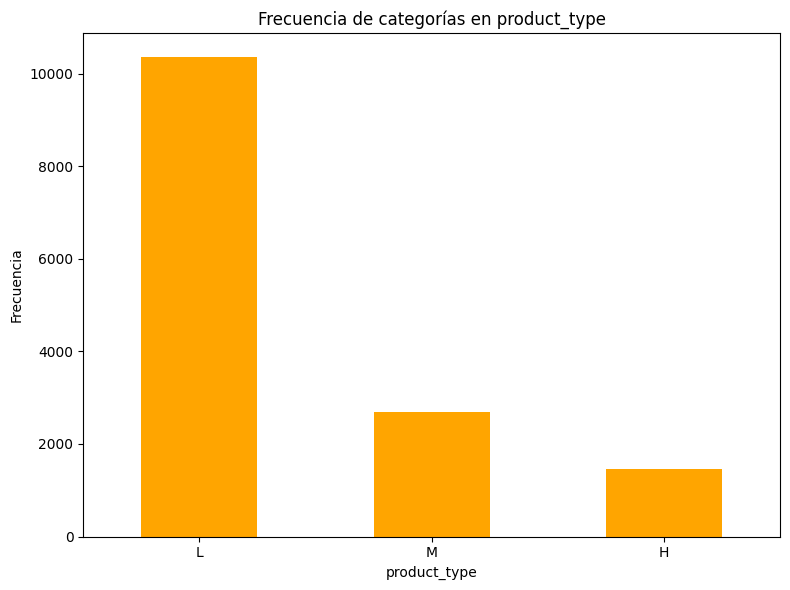

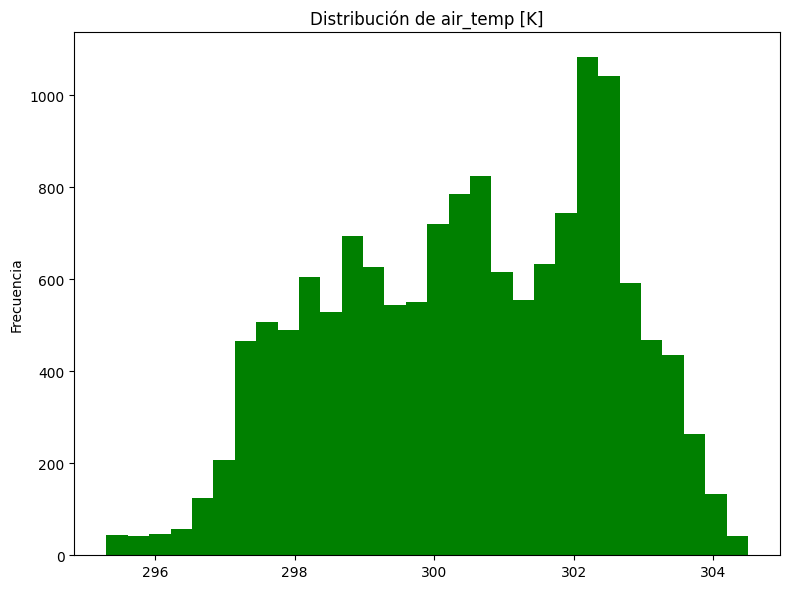

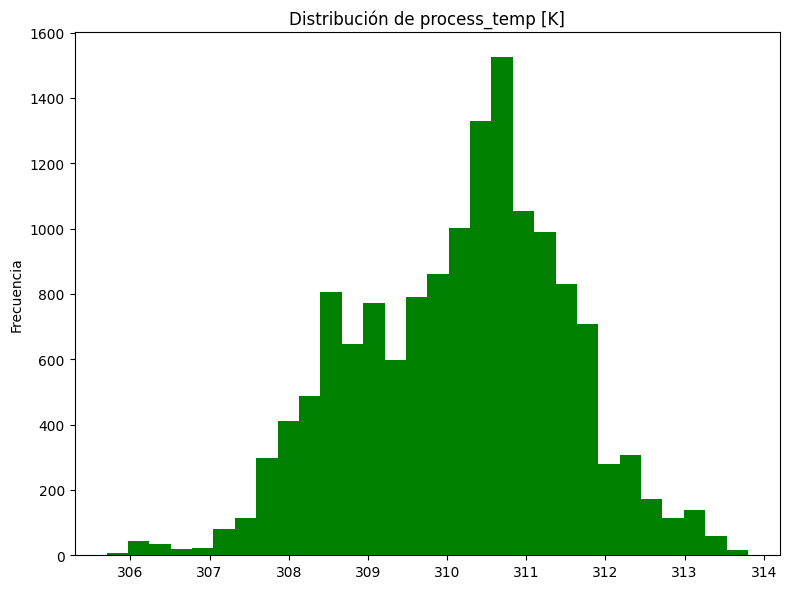

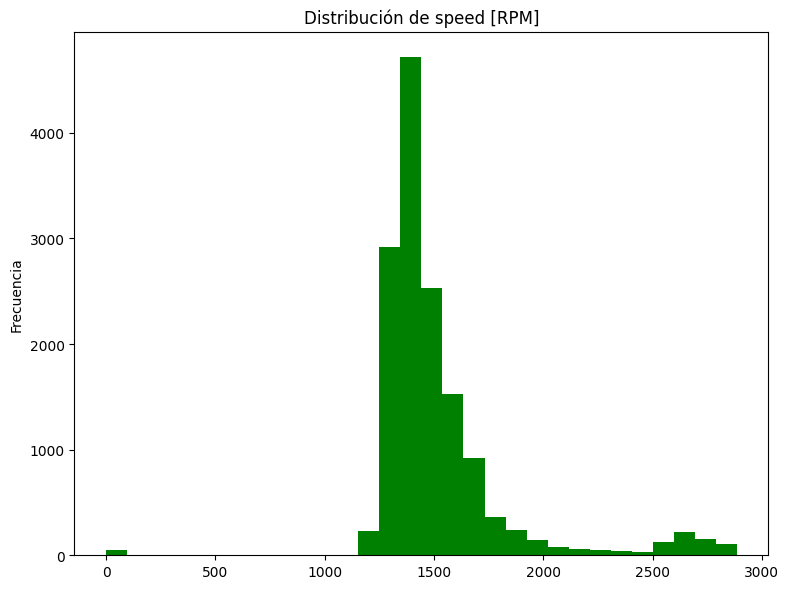

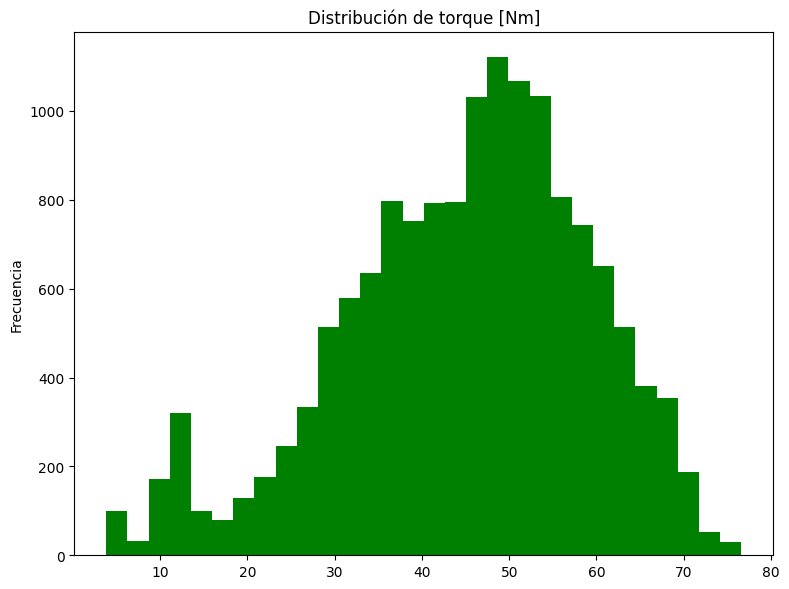

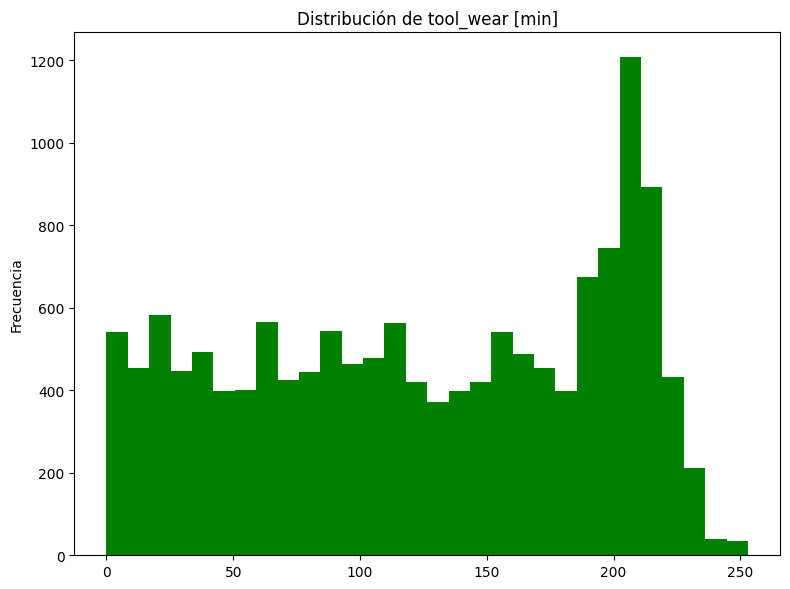

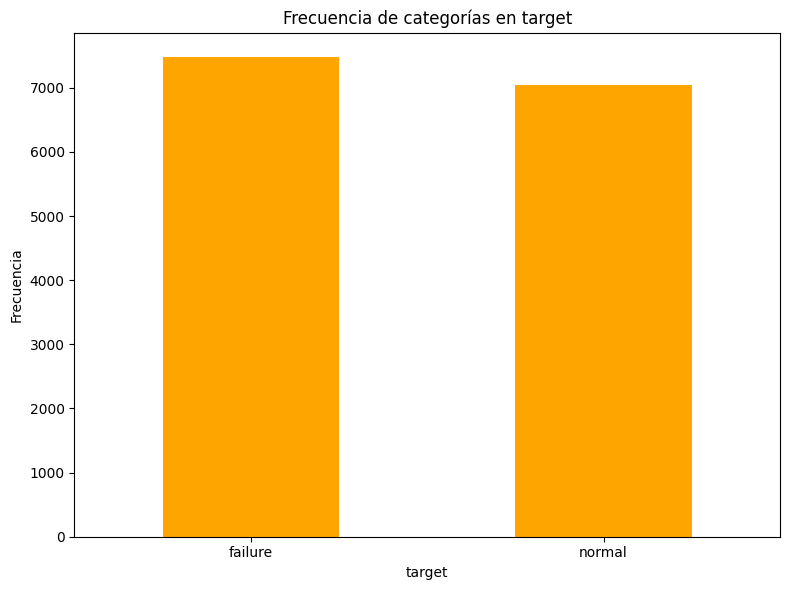

In [ ]:
for columna in df.columns: 
    if columna in ['idx', 'parent_device_id']:
        continue

    plt.figure(figsize=(8, 4))
    plt.ylabel('Frecuencia')

    # Variables numéricas
    if pd.api.types.is_numeric_dtype(df[columna]):
        plt.hist(df[columna], bins=30, color='green')
        plt.title(f'Distribución de {columna}')
    else: 
        # Variables categóricas
        df[columna].value_counts().plot(kind='bar', color='orange')
        plt.title(f'Frecuencia de categorías en {columna}')
        plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()
    

Realizaremos también boxplots, los cuales proporcionan una visión general concisa de la distribución de los datos, desde las tendencias centrales hasta los posibles valores atípicos:

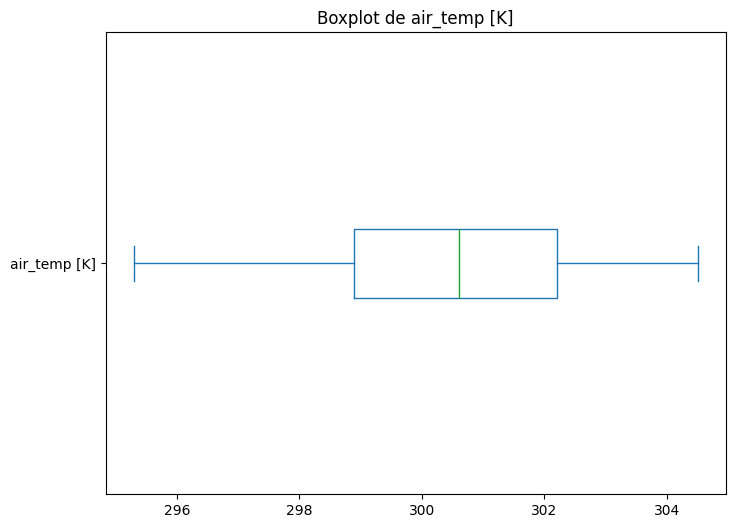

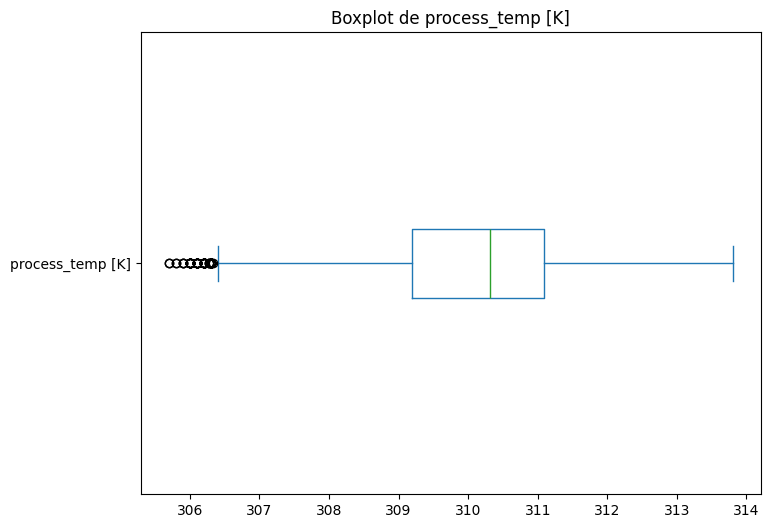

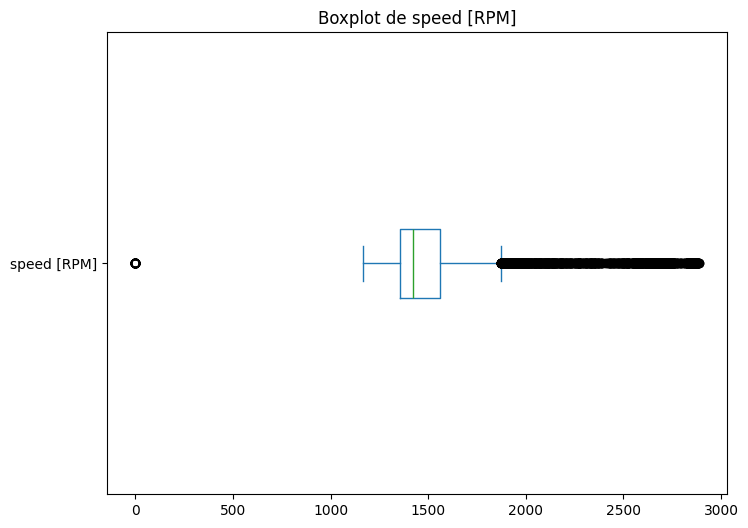

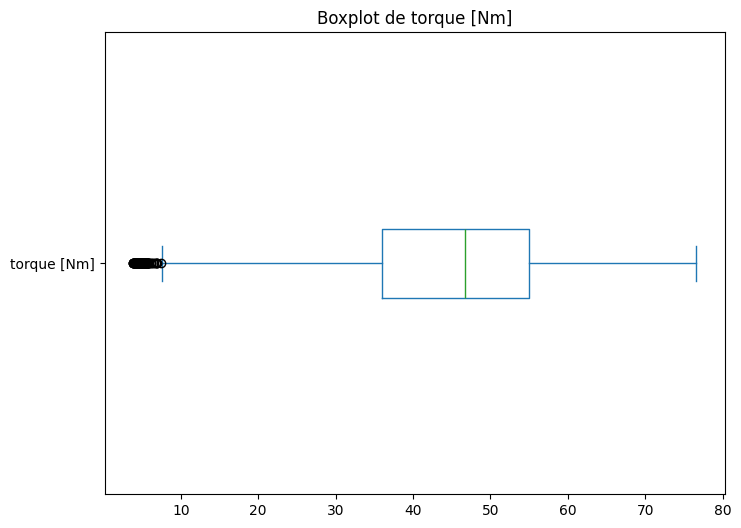

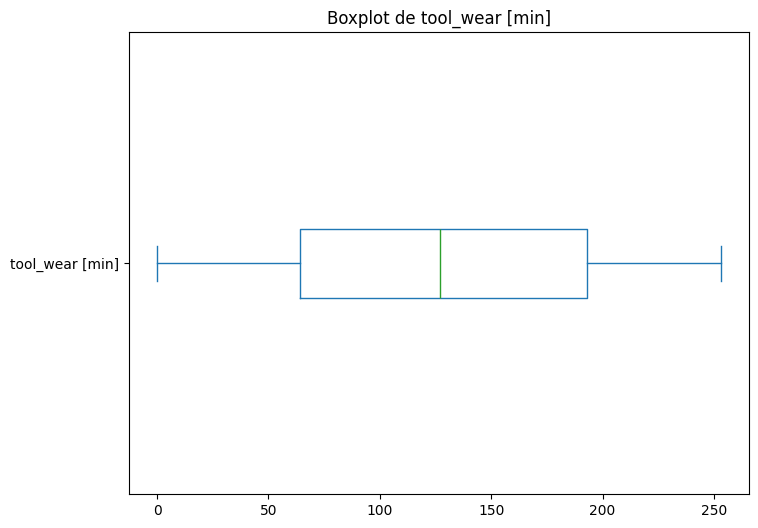

In [13]:
for columna in df.columns: 
    # Excluimos las columnas de id
    if columna not in ['idx', 'parent_device_id']:
    # Generamos boxplot para valores numéricos
        if pd.api.types.is_numeric_dtype(df[columna]):
            plt.figure(figsize=(8, 6))
            df[columna].plot(kind='box', vert=False)
            plt.title(f"Boxplot de {columna}") 
            plt.show()

---
### **Proporciones**
Analizaremos la proporción de los distintos tipos de productos (`product_type`) y la proporción de registros que presentan una falla (`target`):

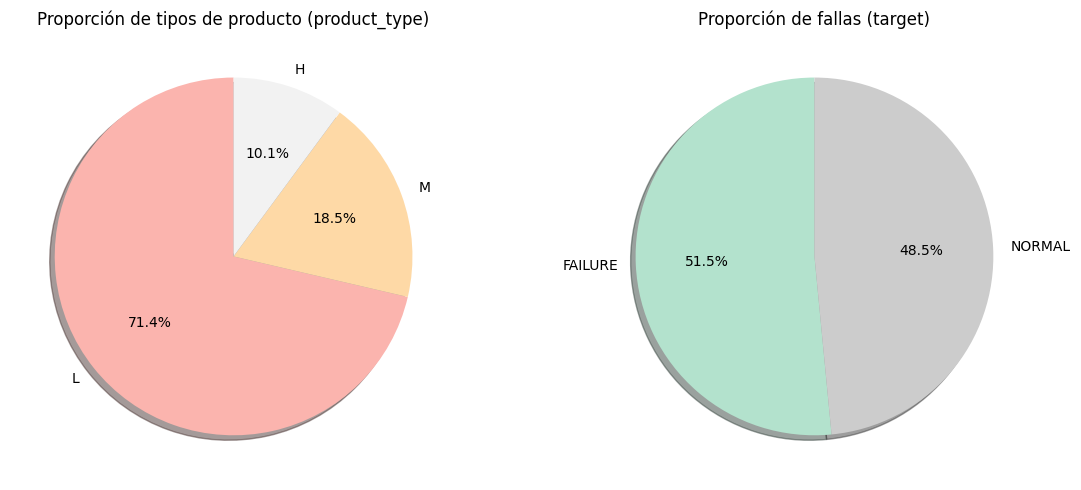

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de torta para la proporción de product_type (tipo de producto)
df['product_type'].str.upper().value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], cmap='Pastel1', startangle=90, shadow=True)
axes[0].set_title('Proporción de tipos de producto (product_type)')
axes[0].set_ylabel('')

# Gráfico de torta para la proporción de target (fallas)
df['target'].str.upper().value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], cmap='Pastel2', startangle=90, shadow=True)
axes[1].set_title('Proporción de fallas (target)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- 
### **Relaciones entre variables**
Para encontrar relaciones, primero visualizaremos la correlación lineal entre todas las variables numéricas mediante un mapa de calor:

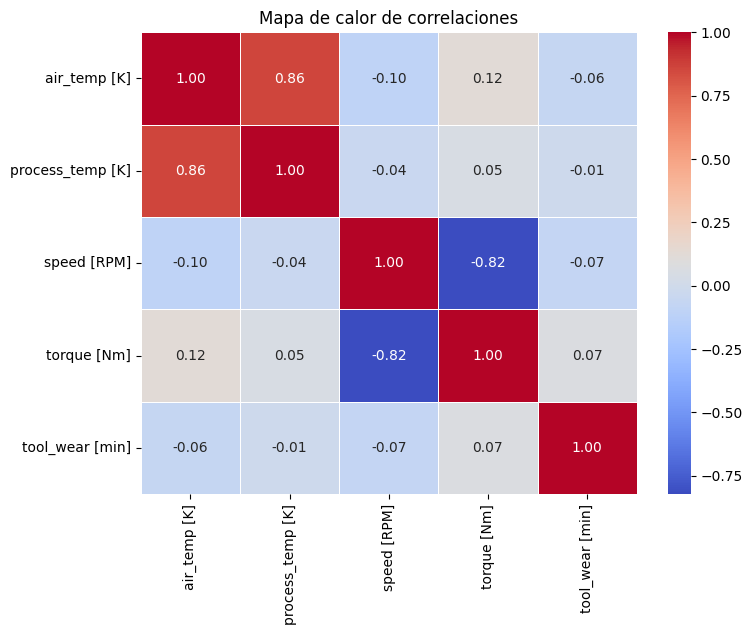

In [15]:
# Filtramos solo las columnas numéricas y eliminamos las columnas de id para no graficarlas innecesariamente
# Luego calculamos la correlación
corr_matrix = df.select_dtypes(include=['number']).drop(columns=['idx', 'parent_device_id']).corr()
plt.figure(figsize=(8, 6))

# Dibujamos el mapa
sns.heatmap(corr_matrix, 
            annot=True,      # Muestra los números adentro de los cuadraditos
            fmt=".2f",       # Formato de 2 decimales
            cmap='coolwarm', # Escala de colores (rojo=caliente/positivo, azul=frío/negativo)
            linewidths=0.5)  # Espacio entre cuadraditos

plt.title("Mapa de calor de correlaciones")
plt.show()

A continuación, realizaremos gráficos de dispesión específicos para analizar cómo interactúan las distintas variables:

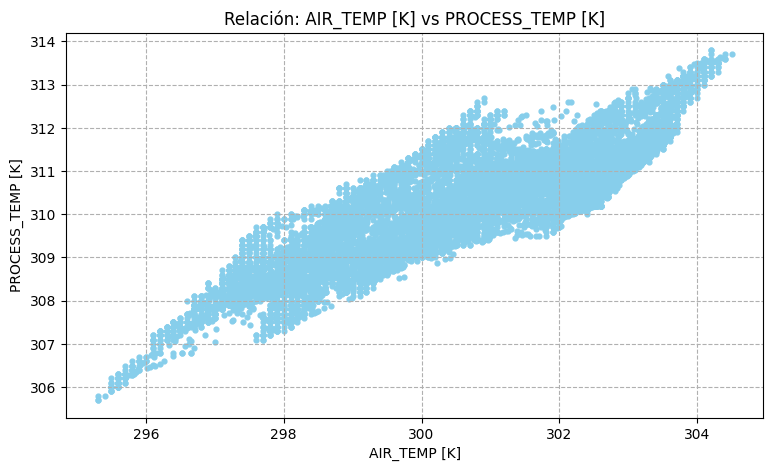

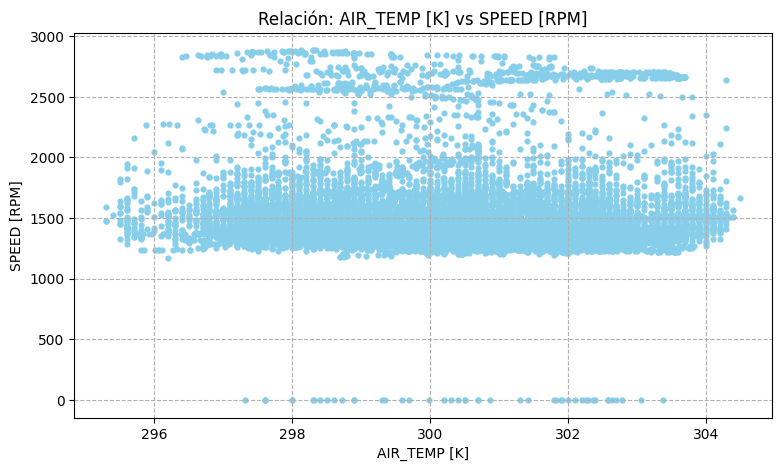

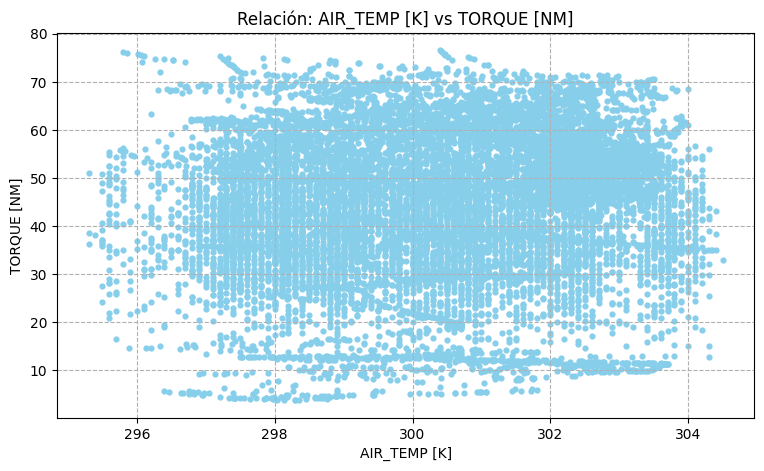

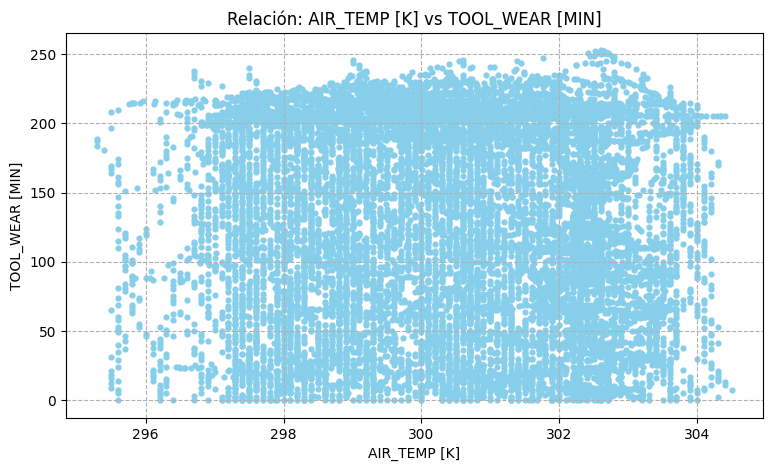

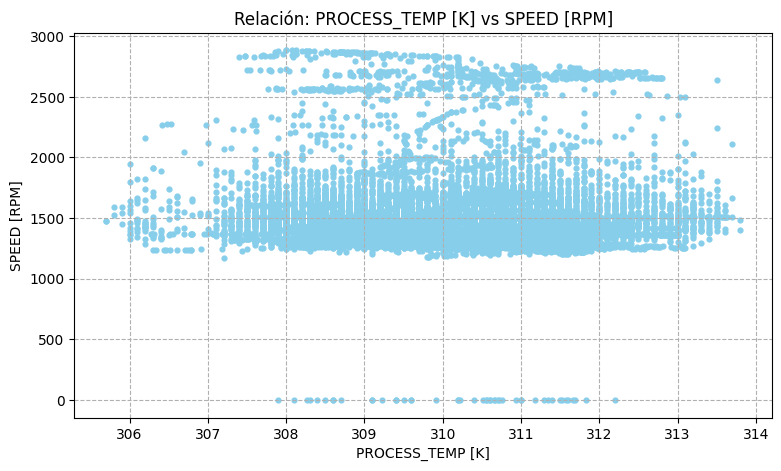

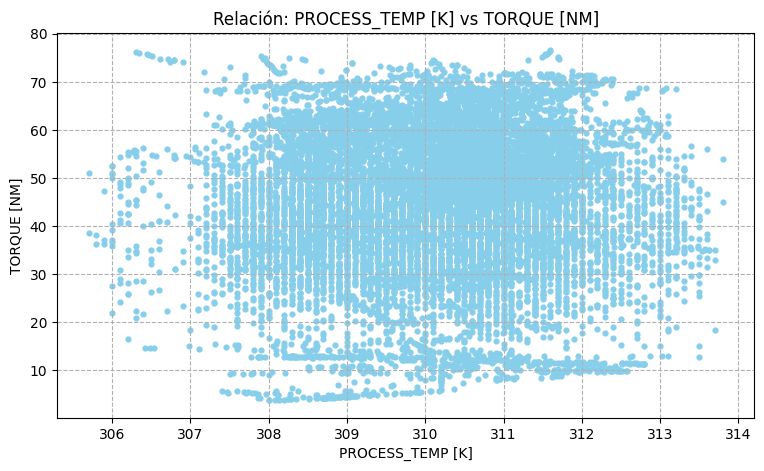

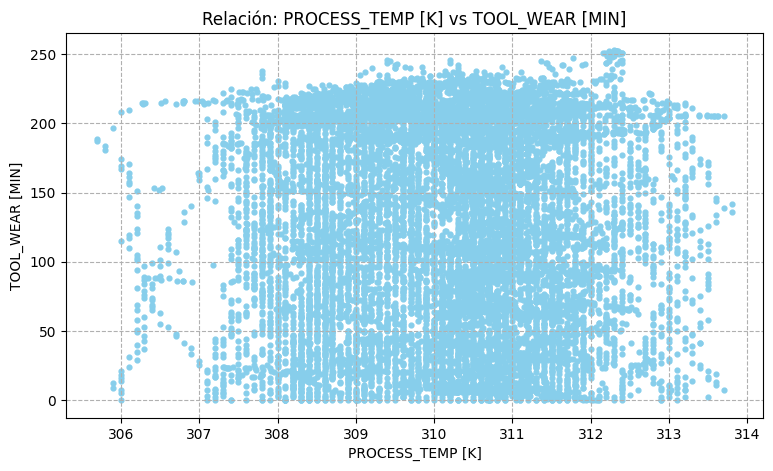

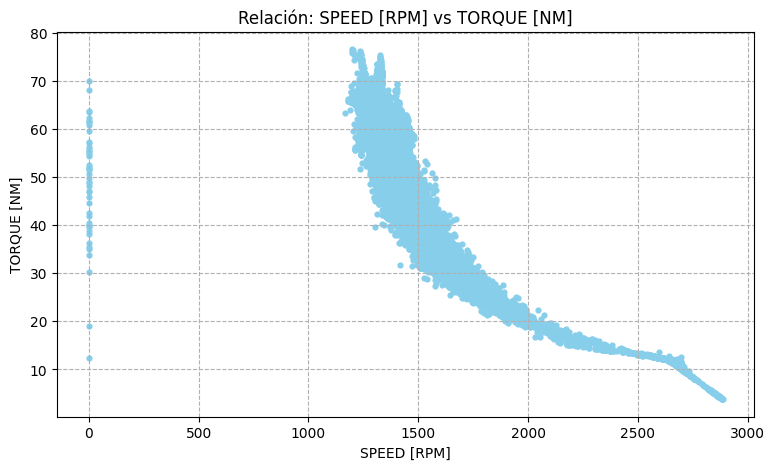

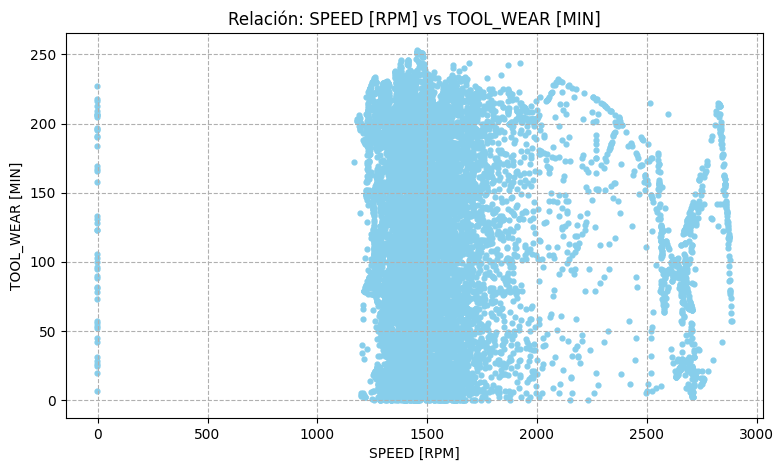

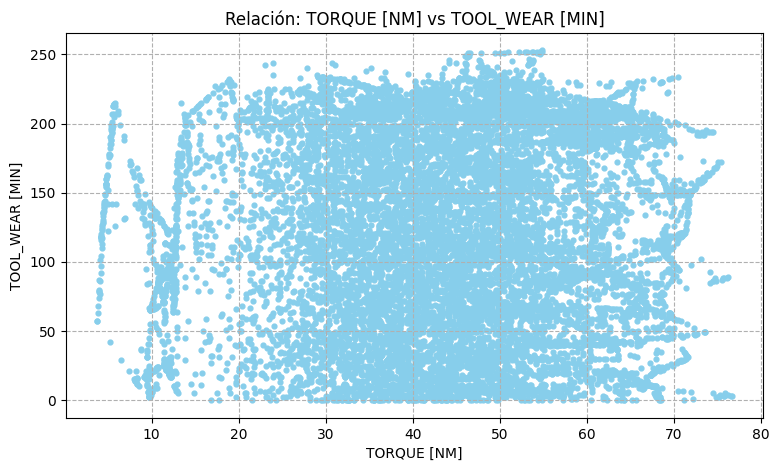

In [16]:
# Seleccionamos las columnas numéricas
cols_numericas = df.select_dtypes(include=['number']).columns

# Eliminamos las columnas de id para no graficarlas innecesariamente
cols_numericas = [c for c in cols_numericas if 'id' not in c.lower() and 'idx' not in c.lower()]

n = len(cols_numericas)

# Bucle para combinar todas con todas
for i in range(n):
    for j in range(i + 1, n):
        col_x = cols_numericas[i]
        col_y = cols_numericas[j]
        
        # Creamos la figura
        plt.figure(figsize=(9, 5))
        
        # Graficamos los puntos
        plt.scatter(df[col_x], df[col_y], color='skyblue', alpha=1, s=12)
        
        plt.title(f"Relación: {col_x.upper()} vs {col_y.upper()}", fontsize=12)
        plt.xlabel(col_x.upper())
        plt.ylabel(col_y.upper())
        plt.grid(True, linestyle='--', alpha=1)
        
        plt.show()

Para finalizar el análisis exploratorio, utilizaremos la función `pairplot` de la librería Seaborn. Esta herramienta permite visualizar de forma masiva los gráficos de dispersión entre todas las variables numéricas del conjunto de datos.

Se ha incluido el parámetro `hue='target'` para colorear los datos según el estado del equipo. Esto es fundamental, ya que nos permite identificar visualmente si ciertas combinaciones de variables tienden a agrupar los casos de falla (color verde) frente a los de funcionamiento normal (color azul).

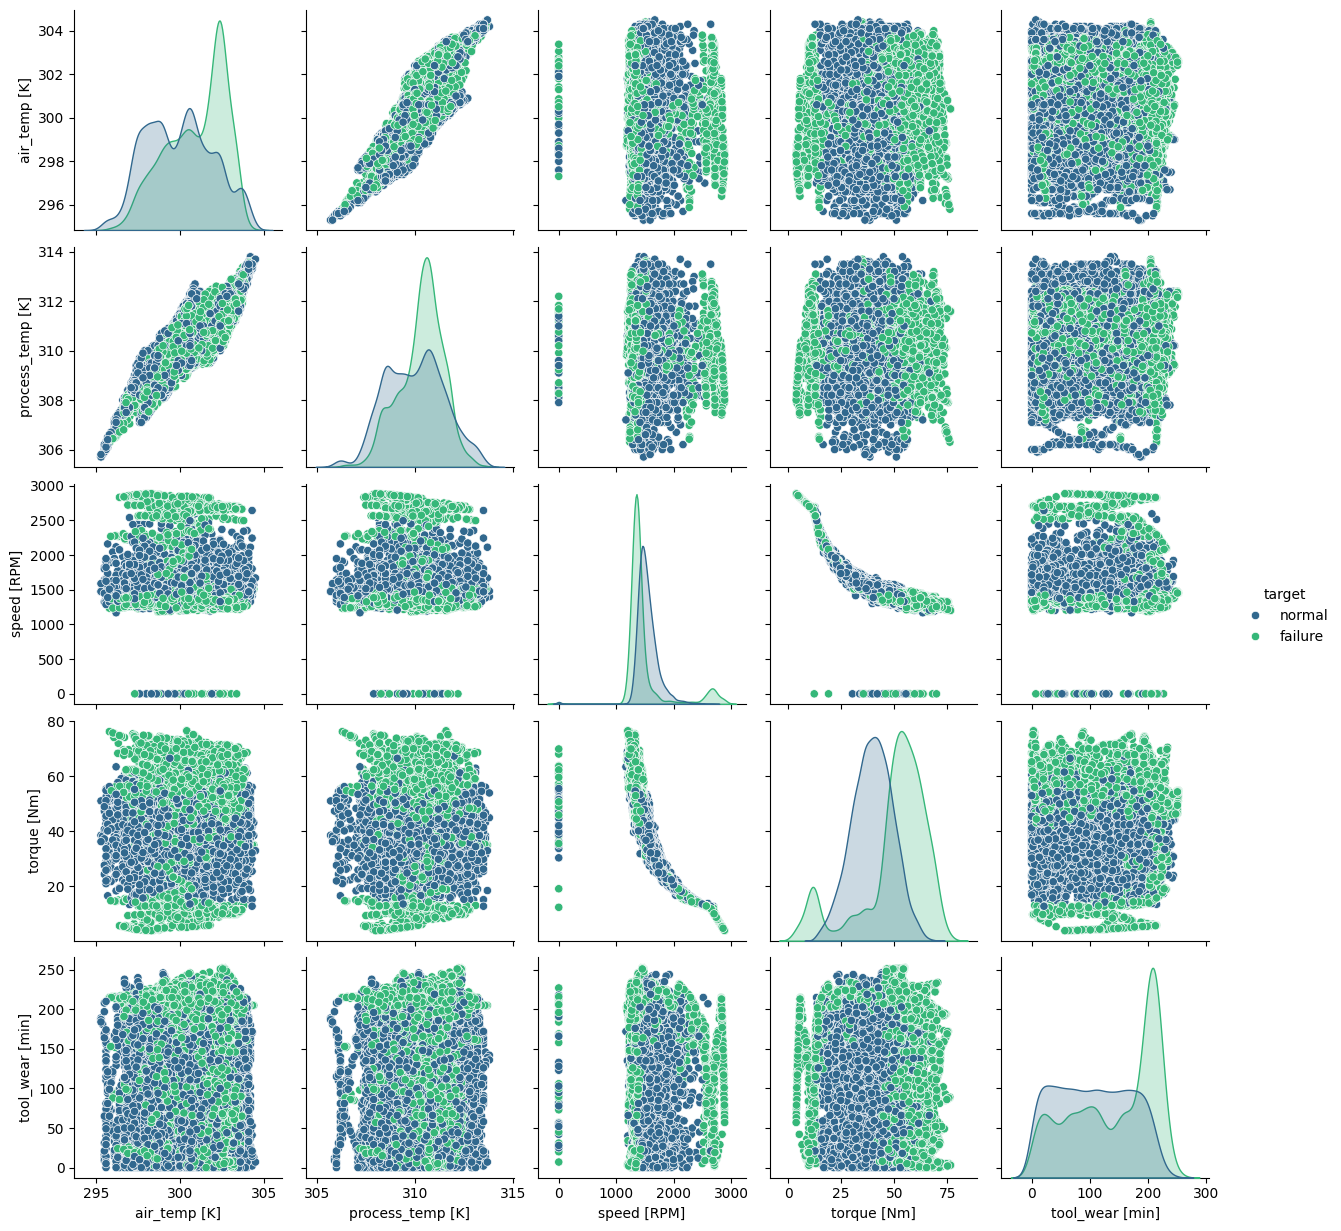

In [18]:
# Visualización masiva de relaciones 
df_relaciones = df[['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]', 'target']]
sns.pairplot(df_relaciones, hue='target', palette='viridis')
plt.show()